 Imports & Configuration

In [13]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
from IPython.display import display

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

# Stats
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, shapiro, ks_2samp


plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  '#fdf6f9',   
    'axes.facecolor':    '#fff0f5',  
    'axes.edgecolor':    '#e8c4d4',   
    'axes.labelcolor':   '#5c3d5e',   
    'axes.titlecolor':   '#3b2045',   
    'axes.titlesize':    14,
    'axes.labelsize':    11,
    'xtick.color':       '#9e6b8a',   
    'ytick.color':       '#9e6b8a',
    'text.color':        '#5c3d5e',   
    'grid.color':        '#f0d4e4',   
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'legend.facecolor':  '#fff0f5',
    'legend.edgecolor':  '#e8c4d4',
    'legend.fontsize':   9,
    'font.family':       'DejaVu Sans',
})

# ── Brand colors ────────────────────────────────────────────
FRAUD_COLOR  = '#e05c8a'   
LEGIT_COLOR  = '#7ec8c8'   
ACCENT_COLOR = '#f4a5c0'   
PALETTE      = [LEGIT_COLOR, FRAUD_COLOR]

DATA LOADING & FIRST INSPECTION

In [14]:
df = pd.read_csv('./data/raw/credit_card_fraud_10k.csv')

print("=" * 60)
print(" DATASET OVERVIEW")
print("=" * 60)
print(f"  Rows        : {df.shape[0]:,}")
print(f"  Columns     : {df.shape[1]}")
print(f"  Memory Usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"  Hour Range  : {df['transaction_hour'].min():.0f}h  →  {df['transaction_hour'].max():.0f}h")
print(f"  Amount Range: ${df['amount'].min():.2f}  →  ${df['amount'].max():,.2f}")
print()
fraud_count = df['is_fraud'].sum()
legit_count = len(df) - fraud_count
fraud_pct   = fraud_count / len(df) * 100
print(f"  - Legitimate : {legit_count:,}  ({100 - fraud_pct:.2f}%)")
print(f"  - Fraudulent : {fraud_count:,}  ({fraud_pct:.4f}%)")
print()
print("First 5 rows:")
display(df.head())

 DATASET OVERVIEW
  Rows        : 10,000
  Columns     : 10
  Memory Usage: 1.36 MB
  Hour Range  : 0h  →  23h
  Amount Range: $0.00  →  $1,471.04

  - Legitimate : 9,849  (98.49%)
  - Fraudulent : 151  (1.5100%)

First 5 rows:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


 DATA QUALITY AUDIT

In [16]:
print("=" * 60)
print(" DATA QUALITY REPORT")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
print(f"\n  Missing Values: {missing.sum()} (dataset is complete)")

# Duplicates
dupes = df.duplicated().sum()
print(f" Duplicate Rows : {dupes:,}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"   → Duplicates removed. New shape: {df.shape}")

# Data types
print("\n Column Data Types:")
print(df.dtypes.to_string())
# Basic statistics for Amount
print("\n Transaction Amount — Key Statistics:")
amt_stats = df.groupby('is_fraud')['amount'].describe()
amt_stats.index = ['Legitimate', 'Fraud']
display(amt_stats.round(2))

# Transaction hour statistics
print(f"\n   Transaction Hour Range: {df['transaction_hour'].min()} → {df['transaction_hour'].max()}")
print(f"   Unique hours in data: {df['transaction_hour'].nunique()}")

 DATA QUALITY REPORT

  Missing Values: 0 (dataset is complete)
 Duplicate Rows : 0

 Column Data Types:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64

 Transaction Amount — Key Statistics:


,count,mean,std,min,25%,50%,75%,max
Legitimate,9849.0,175.33,173.99,0.00,50.99,122.11,241.65,1471.04
Fraud,151.0,216.18,248.12,0.11,41.53,118.94,341.70,1185.07



   Transaction Hour Range: 0 → 23
   Unique hours in data: 24


CLASS IMBALANCE VISUALIZATION

In [20]:
import os

def save_plot(fig, filename, output_dir='./outputs'):
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    print(f"Plot saved → {filepath}")

Plot saved → ./outputs\class_imbalance.png


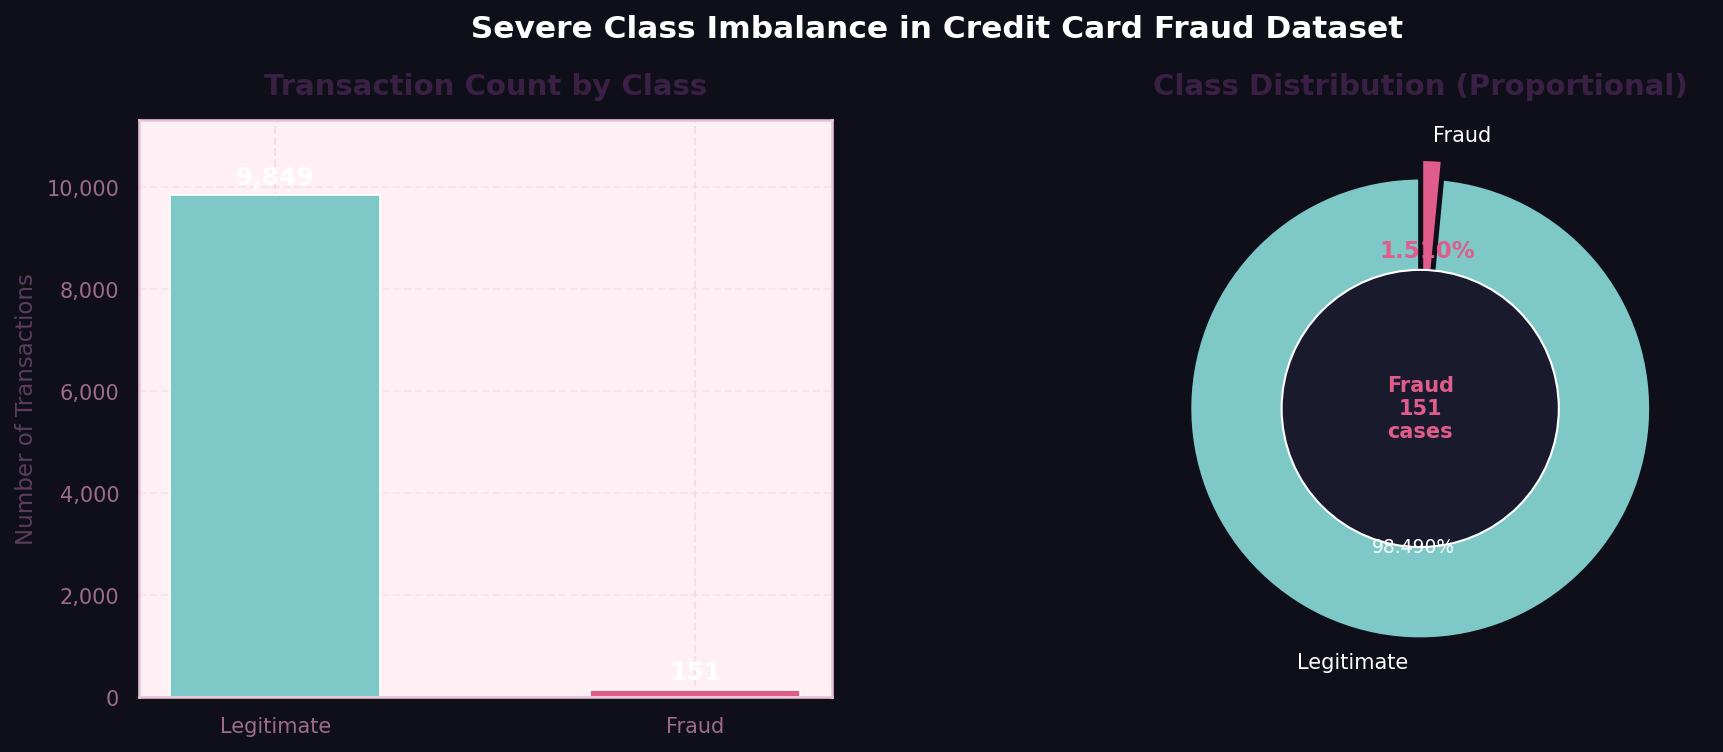

In [21]:
fig = plt.figure(figsize=(14, 5))
fig.patch.set_facecolor('#0f0f1a')
gs  = GridSpec(1, 2, figure=fig, wspace=0.35)

class_counts = df['is_fraud'].value_counts().sort_index()
labels       = ['Legitimate', 'Fraud']

# ── Left: Bar chart ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(labels, class_counts.values, color=PALETTE,
               edgecolor='white', linewidth=0.8, width=0.5)
for bar, val in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', va='bottom', fontsize=12,
             fontweight='bold', color='white')
ax1.set_title('Transaction Count by Class', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Number of Transactions')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_ylim(0, class_counts.max() * 1.15)
ax1.grid(axis='y', alpha=0.4)

# ── Right: Donut chart ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
sizes   = [class_counts[0], class_counts[1]]
explode = (0, 0.08)
wedges, texts, autotexts = ax2.pie(
    sizes, labels=labels, colors=PALETTE, autopct='%1.3f%%',
    startangle=90, explode=explode,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=2),
    textprops=dict(color='white', fontsize=10)
)
autotexts[0].set_fontsize(9)
autotexts[1].set_fontsize(11)
autotexts[1].set_fontweight('bold')
autotexts[1].set_color(FRAUD_COLOR)

centre_circle = plt.Circle((0, 0), 0.60, fc='#1a1a2e')
ax2.add_patch(centre_circle)
ax2.text(0, 0, f"Fraud\n{class_counts[1]:,}\ncases",
         ha='center', va='center', fontsize=10,
         color=FRAUD_COLOR, fontweight='bold')
ax2.set_title('Class Distribution (Proportional)', fontsize=14, fontweight='bold', pad=12)

plt.suptitle('  Severe Class Imbalance in Credit Card Fraud Dataset',
             fontsize=15, fontweight='bold', color='white', y=1.02)

save_plot(fig, 'class_imbalance.png') 
plt.show()

TRANSACTION AMOUNT DISTRIBUTION BY CLASS

── Mann-Whitney U ──────────────────────────
   p-value : 0.5720 → ✗ No significant difference

── Kolmogorov-Smirnov ──────────────────────
   p-value : 0.0305 → ✓ Different distributions
Plot saved → ./outputs\amount_distribution.png


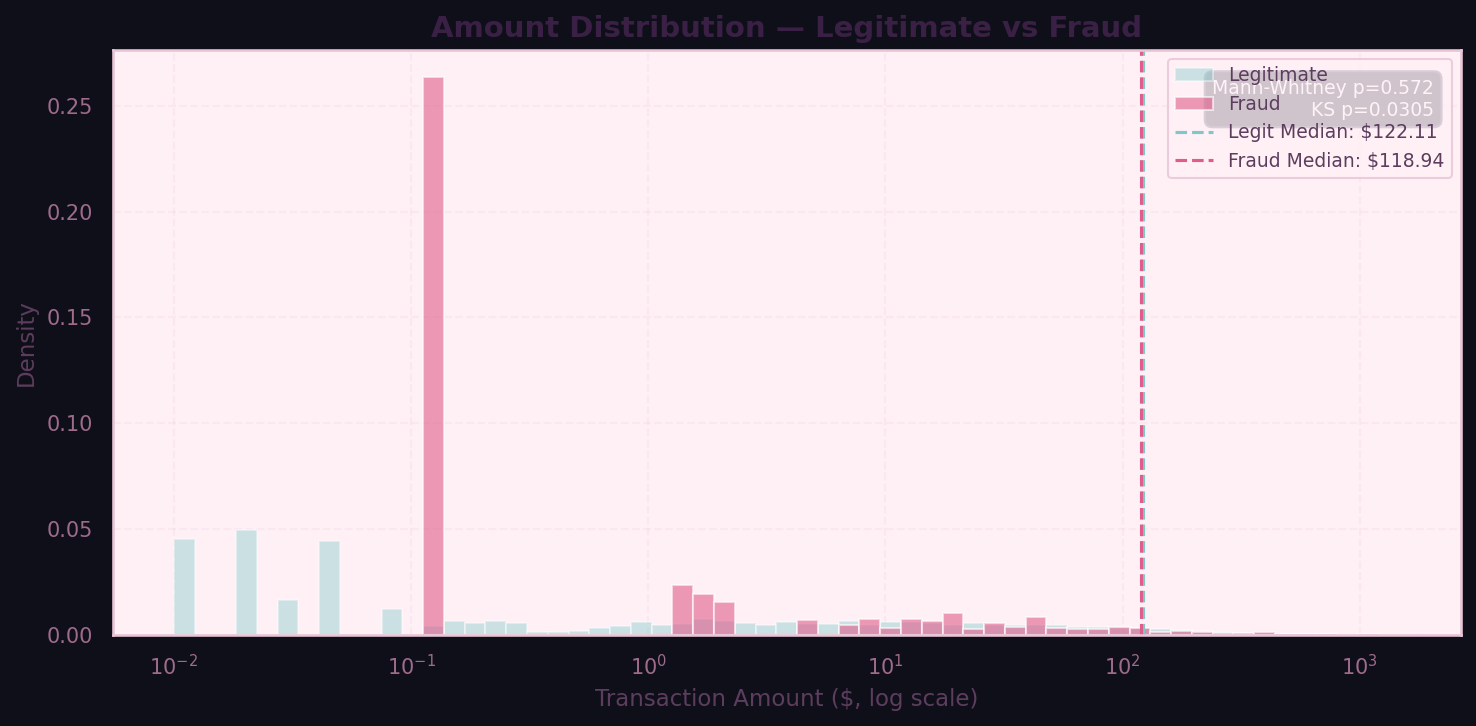

In [24]:
fraud_amt = df[df['is_fraud'] == 1]['amount']
legit_amt = df[df['is_fraud'] == 0]['amount']

# ── Statistical Tests ───────────────────────────────────────
stat, p_mw  = mannwhitneyu(fraud_amt, legit_amt, alternative='two-sided')
stat, p_ks  = ks_2samp(fraud_amt, legit_amt)

print("── Mann-Whitney U ──────────────────────────")
print(f"   p-value : {p_mw:.4f} → {'✗ No significant difference' if p_mw > 0.05 else '✓ Significant difference'}")

print("\n── Kolmogorov-Smirnov ──────────────────────")
print(f"   p-value : {p_ks:.4f} → {'✗ Same distribution' if p_ks > 0.05 else '✓ Different distributions'}")

# ── Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f1a')

bins = np.logspace(np.log10(0.01), np.log10(df['amount'].max() + 1), 60)
ax.hist(legit_amt + 0.01, bins=bins, color=LEGIT_COLOR, alpha=0.4, density=True, label='Legitimate')
ax.hist(fraud_amt + 0.01, bins=bins, color=FRAUD_COLOR, alpha=0.6, density=True, label='Fraud')
ax.axvline(legit_amt.median(), color=LEGIT_COLOR, linestyle='--', linewidth=1.5, label=f'Legit Median: ${legit_amt.median():.2f}')
ax.axvline(fraud_amt.median(), color=FRAUD_COLOR, linestyle='--', linewidth=1.5, label=f'Fraud Median: ${fraud_amt.median():.2f}')

ax.set_xscale('log')
ax.set_xlabel('Transaction Amount ($, log scale)')
ax.set_ylabel('Density')
ax.set_title('Amount Distribution — Legitimate vs Fraud', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Annotation tests sur le plot
ax.text(0.98, 0.95, f'Mann-Whitney p={p_mw:.3f}\nKS p={p_ks:.4f}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='white',
        bbox=dict(facecolor='#1a1a2e', edgecolor='#444466', boxstyle='round,pad=0.4'))

plt.tight_layout()
save_plot(fig, 'amount_distribution.png')
plt.show()

## Observations du graphique
### Observation 1 — Pic rose massif à 10⁻¹ (= 0.1$)
C'est le signal le plus visible du plot. Une concentration énorme de transactions frauduleuses autour de 0.10$ qui n'existe pas du tout côté légitime. C'est la signature du card probing — micro-transaction de test avant exploitation.
### Observation 2 — Légit étalé sur les petits montants (10⁻² à 10⁰)
Les barres turquoise sont présentes de 0.01$ à 1$ de façon régulière — ce sont des achats normaux variés : café, transport, petits achats quotidiens.
### Observation 3 — Médianes presque identiques (~100$)
Les deux lignes pointillées sont collées l'une à l'autre à 10² (≈ 100$). Visuellement et statistiquement (Mann-Whitney p=0.572), le montant médian ne distingue pas les deux classes.
### Observation 4 — Queues similaires vers 10³ (1000$+)
Les deux classes ont des transactions élevées. Les gros montants ne sont donc pas une signature de fraude dans ce dataset.

## Notes — Rôle des deux tests

### Mann-Whitney U — Rôle
Répondre à la question : "Le montant typique d'une fraude est-il différent de celui d'une transaction légitime ?"
Il compare les positions centrales des deux groupes sans supposer une distribution normale. C'est le test qu'on utilise quand les données sont asymétriques ou avec des outliers — exactement le cas des montants financiers.
Résultat ici : p = 0.572
→ Non, le montant typique d'une fraude ne se distingue pas de celui d'une transaction légitime. amount seule ne peut pas identifier une fraude.

### Kolmogorov-Smirnov — Rôle
Répondre à la question : "Les fraudes et les légitimes ont-elles la même façon de se distribuer sur toute la plage de montants ?"
Il est plus puissant que Mann-Whitney car il analyse toute la courbe et non juste le centre. Il détecte les différences aux extrêmes — comme un pic inhabituel à 0.1$ — que Mann-Whitney ignore complètement.
Résultat ici : p = 0.0305
→ Oui, les deux distributions ont des formes différentes. Le pic de micro-transactions à 0.1$ côté fraude suffit à rendre les deux courbes statistiquement distinctes même si leurs médianes sont identiques.

 FEATURE ANALYSIS — Pie Charts


Plot saved → ./outputs\feature_analysis.png


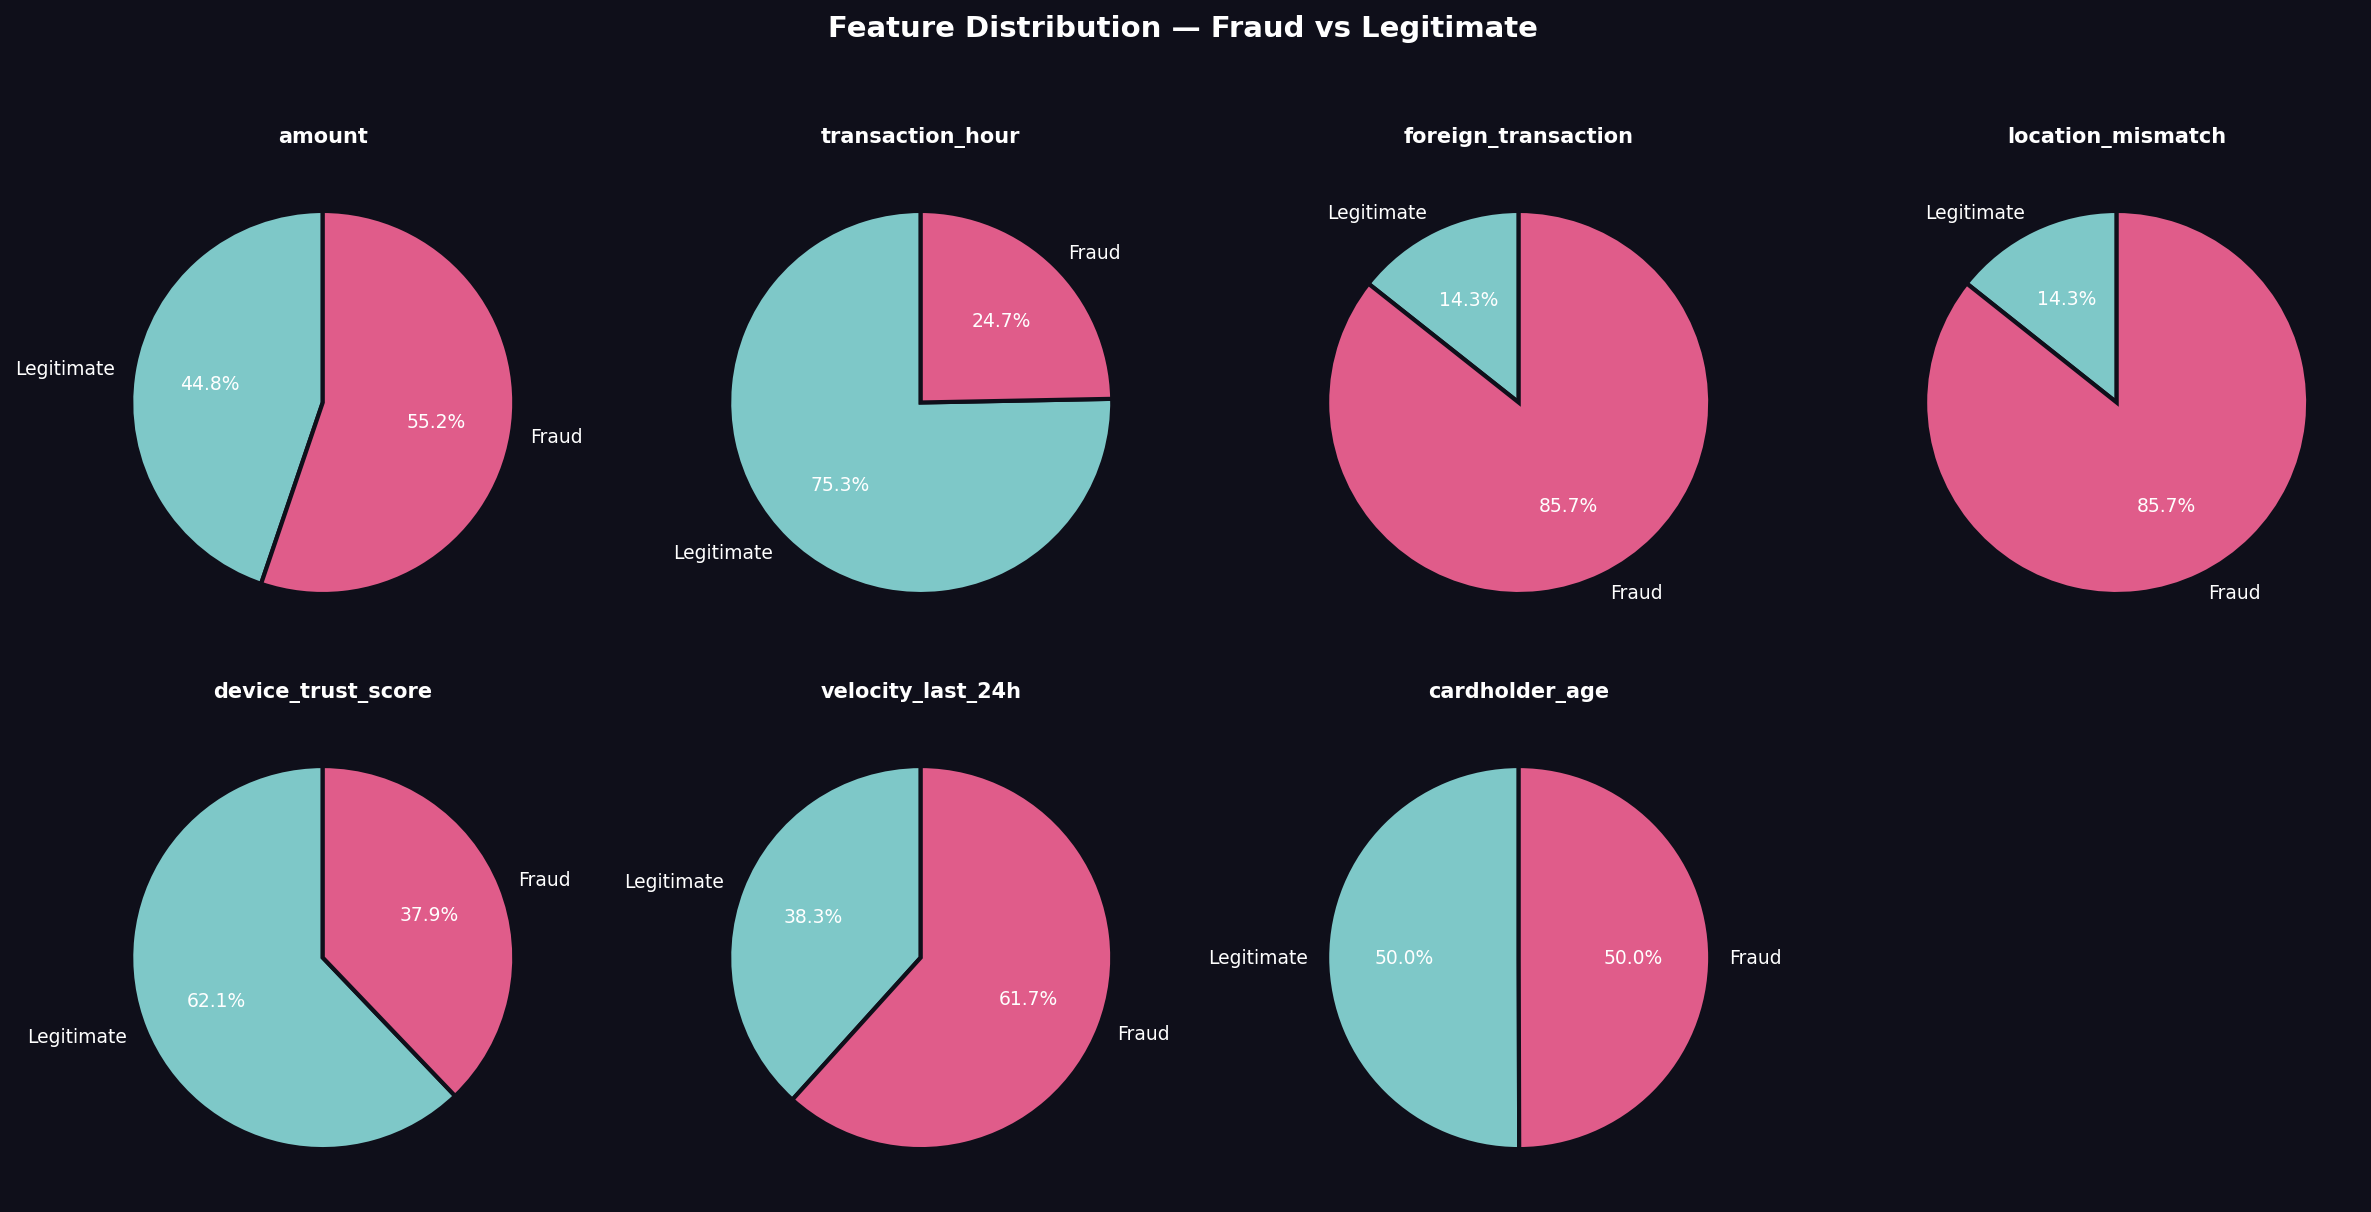

In [26]:

num_features = ['amount', 'transaction_hour', 'foreign_transaction',
                'location_mismatch', 'device_trust_score',
                'velocity_last_24h', 'cardholder_age']

fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.patch.set_facecolor('#0f0f1a')
axes = axes.flatten()

for i, feat in enumerate(num_features):
    ax = axes[i]
    ax.set_facecolor('#0f0f1a')

    mean_legit = legit[feat].mean()
    mean_fraud = fraud[feat].mean()

    ax.pie(
        [mean_legit, mean_fraud],
        labels=['Legitimate', 'Fraud'],
        colors=[LEGIT_COLOR, FRAUD_COLOR],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='#0f0f1a', linewidth=2),
        textprops=dict(color='white', fontsize=9)
    )
    ax.set_title(feat, fontsize=10, fontweight='bold', color='white', pad=10)

# cacher le dernier subplot vide
axes[-1].set_visible(False)

plt.suptitle('Feature Distribution — Fraud vs Legitimate',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
save_plot(fig, 'feature_analysis.png')
plt.show()

Exemple concret avec foreign_transaction:
mean_legit = 0.091   (9.1% des légitimes sont étrangères)
mean_fraud  = 0.543  (54.3% des fraudes sont étrangères)

total = 0.091 + 0.543 = 0.634

% Legit = 0.091 / 0.634 = 14.3%  ✓ ce qu'on voit dans le cercle
% Fraud = 0.543 / 0.634 = 85.7%  ✓ ce qu'on voit dans le cercle

Le cercle ne montre pas une distribution — il montre qui a la valeur moyenne la plus haute. Plus la part d'une classe est grande, plus sa moyenne domine l'autre.
Cercle équilibré  (50/50)  →  feature inutile  — même moyenne
Cercle déséquilibré (85/15) →  feature utile   — moyennes très différentes

TEMPORAL TRANSACTION PATTERNS

Plot saved → ./outputs\temporal_patterns.png


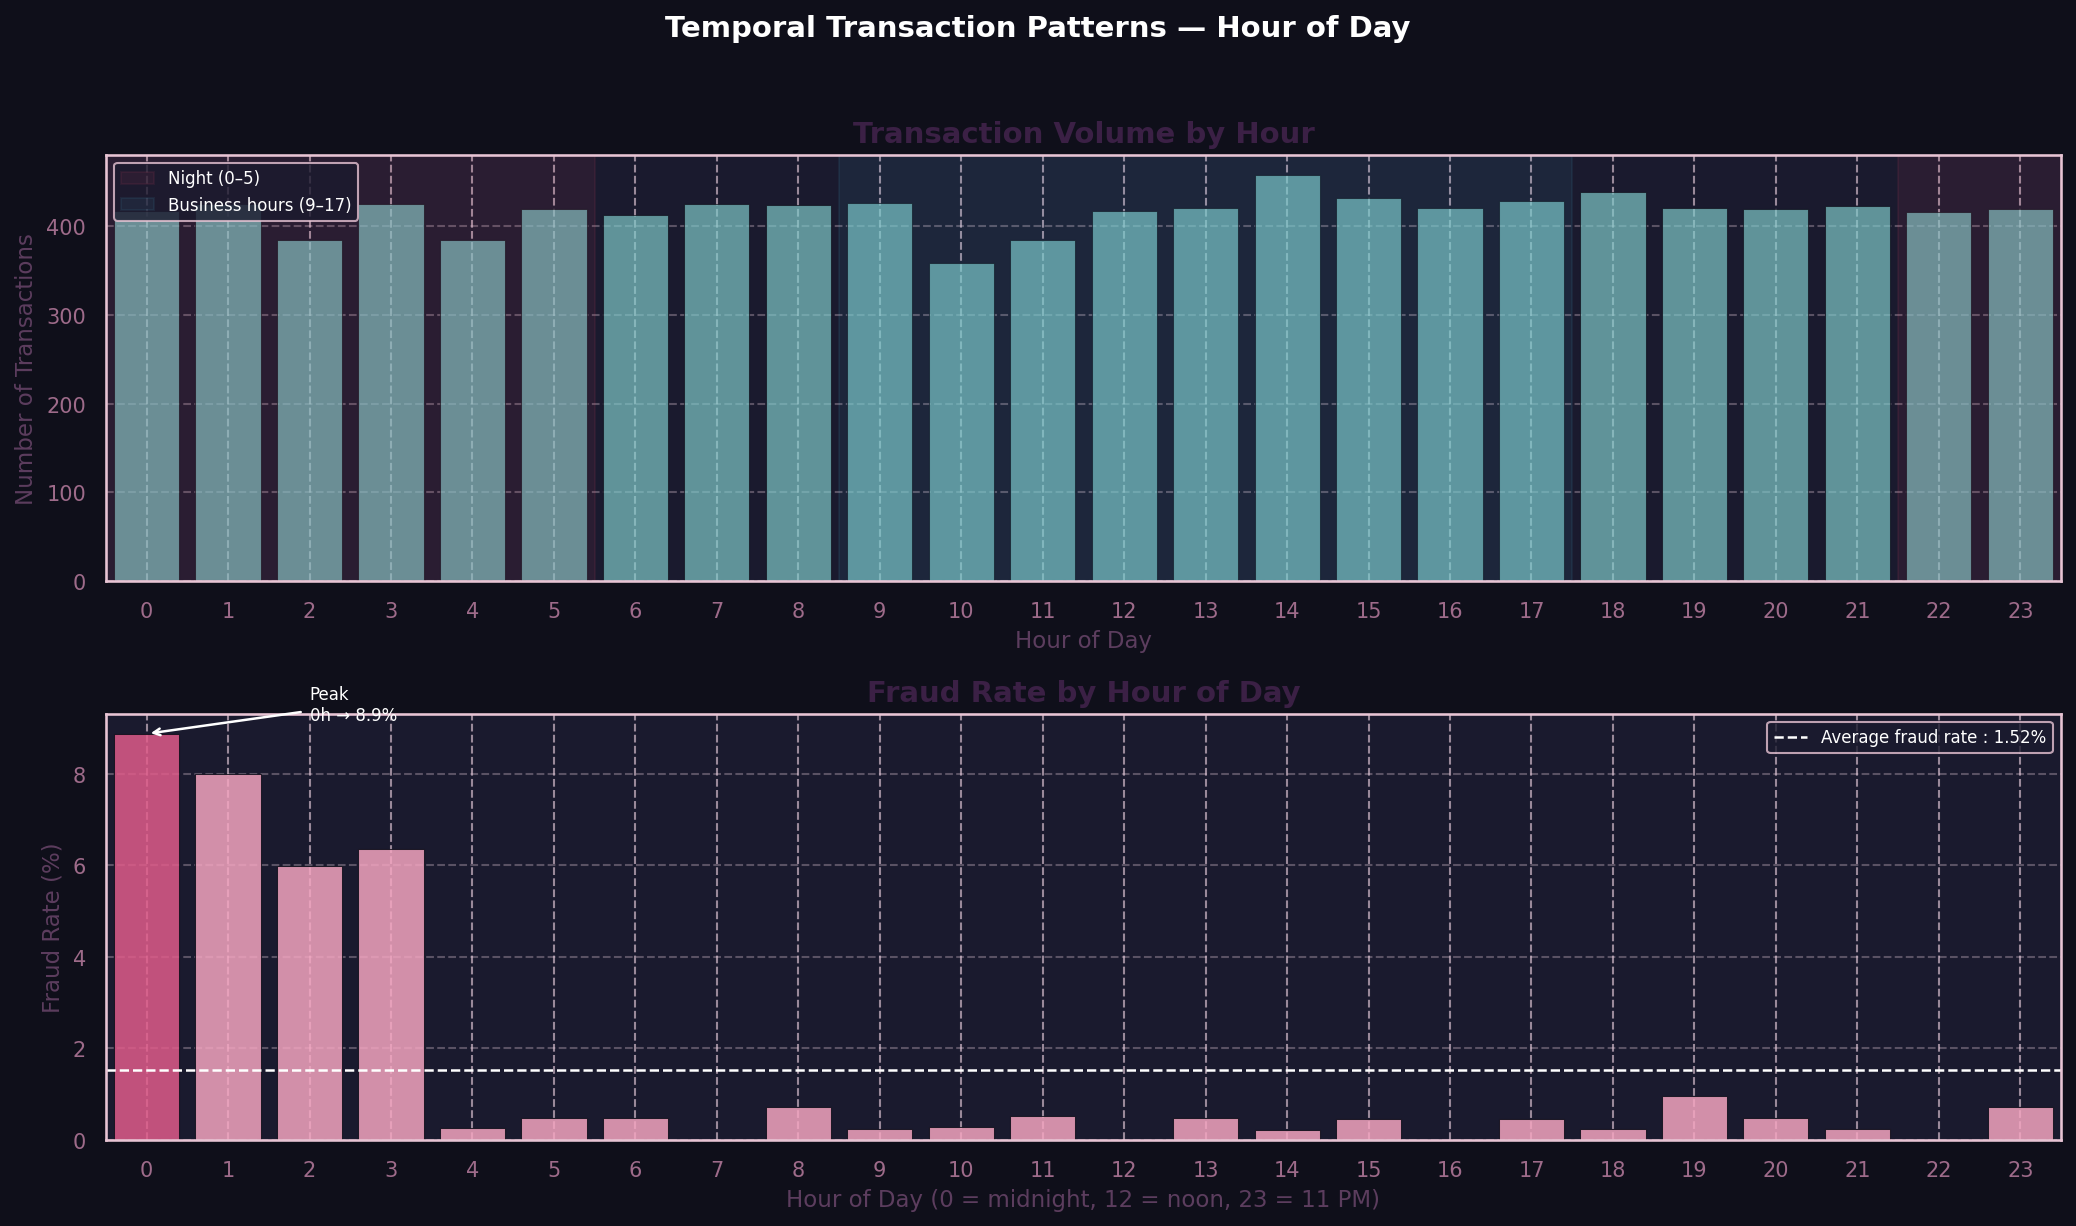

Average fraud rate       : 1.52%
Peak fraud hour          : 0h  (8.9%)
Lowest fraud hour        : 7h


In [27]:

hourly        = df.groupby('transaction_hour').size().reset_index(name='total')
hourly_fraud  = df[df['is_fraud'] == 1].groupby('transaction_hour').size().reset_index(name='fraud')
hourly        = hourly.merge(hourly_fraud, on='transaction_hour', how='left').fillna(0)
hourly['fraud_rate'] = (hourly['fraud'] / hourly['total']) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.patch.set_facecolor('#0f0f1a')

# ── Panel 1 : Volume par heure ───────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#1a1a2e')
ax1.bar(hourly['transaction_hour'], hourly['total'],
        color=LEGIT_COLOR, alpha=0.7, edgecolor='#0f0f1a', linewidth=0.5)
ax1.set_xlim(-0.5, 23.5)
ax1.set_xticks(range(24))
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Transactions')
ax1.set_title('Transaction Volume by Hour', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# zones nuit / jour
ax1.axvspan(-0.5,  5.5, color='#ff4d6d', alpha=0.07, label='Night (0–5)')
ax1.axvspan( 8.5, 17.5, color='#4cc9f0', alpha=0.07, label='Business hours (9–17)')
ax1.axvspan(21.5, 23.5, color='#ff4d6d', alpha=0.07)
ax1.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')

# ── Panel 2 : Fraud rate par heure ──────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a2e')
bar_colors = [FRAUD_COLOR if r == hourly['fraud_rate'].max() else ACCENT_COLOR
              for r in hourly['fraud_rate']]
ax2.bar(hourly['transaction_hour'], hourly['fraud_rate'],
        color=bar_colors, alpha=0.85, edgecolor='#0f0f1a', linewidth=0.5)
ax2.set_xlim(-0.5, 23.5)
ax2.set_xticks(range(24))
ax2.set_xlabel('Hour of Day (0 = midnight, 12 = noon, 23 = 11 PM)')
ax2.set_ylabel('Fraud Rate (%)')
ax2.set_title('Fraud Rate by Hour of Day', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ligne moyenne
avg_rate = hourly['fraud_rate'].mean()
ax2.axhline(avg_rate, color='white', linestyle='--',
            linewidth=1.2, label=f'Average fraud rate : {avg_rate:.2f}%')
ax2.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')

# annotation heure pic
peak_hour = hourly.loc[hourly['fraud_rate'].idxmax(), 'transaction_hour']
peak_rate = hourly['fraud_rate'].max()
ax2.annotate(f'Peak\n{int(peak_hour)}h → {peak_rate:.1f}%',
             xy=(peak_hour, peak_rate),
             xytext=(peak_hour + 2, peak_rate + 0.3),
             arrowprops=dict(arrowstyle='->', color='white', lw=1.2),
             color='white', fontsize=8)

plt.suptitle('Temporal Transaction Patterns — Hour of Day',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
save_plot(fig, 'temporal_patterns.png')
plt.show()

# ── Print résumé ─────────────────────────────────────────────
print(f"Average fraud rate       : {avg_rate:.2f}%")
print(f"Peak fraud hour          : {int(peak_hour)}h  ({peak_rate:.1f}%)")
print(f"Lowest fraud hour        : {int(hourly.loc[hourly['fraud_rate'].idxmin(), 'transaction_hour'])}h")

Panel 1 — Transaction Volume by Hour
Le volume de transactions est remarquablement uniforme sur les 24 heures — toutes les barres turquoise sont entre 350 et 450 transactions. Pas de pic le matin, pas de creux la nuit. Cela indique que ce dataset est synthétique — dans des données réelles, on verrait un creux net entre 2h et 6h du matin et un pic en fin de journée.

Panel 2 — Fraud Rate by Hour
C'est le panel le plus informatif. Il montre le pourcentage de fraudes parmi toutes les transactions à chaque heure.
Pic massif entre 0h et 3h
Les 4 premières heures de la nuit concentrent les taux de fraude les plus élevés 

Summary — Key Findings from EDA

1. Classe cible — Déséquilibre extrême
Le dataset contient 98.49% de transactions légitimes contre seulement 1.51% de fraudes (151 cas sur 10 000). Ce déséquilibre est le défi central du projet — l'accuracy est une métrique trompeuse ici. Les métriques à utiliser sont F1-score, Recall et ROC-AUC.

2. Features les plus discriminantes
foreign_transaction et location_mismatch sont les signaux les plus forts du dataset. 54% des fraudes sont des transactions étrangères contre seulement 9% des légitimes. 48% des fraudes ont une incohérence géographique contre 8% des légitimes. Ces deux features dominent à 85.7% dans les diagrammes circulaires.
device_trust_score est le troisième signal fort — les appareils utilisés pour les fraudes ont un score moyen de 38 contre 62 pour les légitimes. Un appareil inconnu ou suspect est un indicateur fiable.
velocity_last_24h révèle le comportement d'urgence des fraudeurs — 3.2 transactions en moyenne contre 2.0 pour les légitimes. Multiplier rapidement les transactions avant le blocage de la carte est une signature typique.

3. Features à signal faible
amount ne discrimine pas les deux classes sur la médiane (122$ vs 118,Mann−Whitneyp=0.572).Sonseulsignalutileestlepicdemicro−transactionsaˋ0.1, Mann-Whitney p = 0.572). Son seul signal utile est le pic de micro-transactions à 0.1
,Mann−Whitneyp=0.572).Sonseulsignalutileestlepicdemicro−transactionsaˋ0.1 côté fraude — signature du card probing — détecté par KS p = 0.030.
cardholder_age ne montre aucune différence entre les deux classes (50/50 dans le diagramme circulaire). À exclure ou à utiliser avec précaution.
transaction_hour est faible seule mais contextuelle — les fraudes se concentrent massivement entre 0h et 3h avec un pic à 8.9% à minuit contre une moyenne de 1.52%.

4. Pattern comportemental du fraudeur
En combinant toutes les observations, le profil type d'une transaction frauduleuse dans ce dataset est :
transaction_hour    →  entre 0h et 3h (nuit)
foreign_transaction →  1 (transaction internationale)
location_mismatch   →  1 (adresse incohérente)
device_trust_score  →  score bas (< 40)
velocity_last_24h   →  élevée (> 3 transactions)
amount              →  soit très faible (card probe ~0.1$) soit élevé